In [26]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat
/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv
/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/zerotrace11/tech-company-dataset/tech_company_employee_data_1000.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_test.csv


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
uci = pd.read_csv('/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv')
diabetes = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
house = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')

# impute missing values of occupation column of uci dataset

In [29]:

print(uci['Occupation'].isnull().sum())

replaced_by = uci['Occupation'].mode()[0]
uci['Occupation'] = uci['Occupation'].fillna(replaced_by)

print(uci['Occupation'].isnull().sum())

1843
0


# Outliers

# 1. find and mitigate(trimming and capping both) outliers on age column of diabetes dataset

Missing values: 0
Skewness: -0.05197899678256747


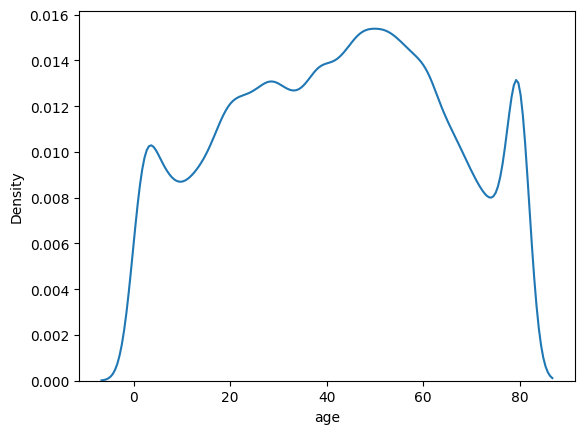

count    100000.000000
mean         41.885856
std          22.516840
min           0.080000
25%          24.000000
50%          43.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64

In [30]:
diabetes['age']

print("Missing values:",diabetes['age'].isnull().sum())
print("Skewness:",diabetes['age'].skew())

sns.kdeplot(data = diabetes, x = 'age')
plt.show()

diabetes['age'].describe()

In [31]:
print("mean age",diabetes['age'].mean())
print("std",diabetes['age'].std())

Upper = diabetes['age'].mean() + 3* diabetes['age'].std()

x = diabetes['age'].mean() - 3* diabetes['age'].std()
lower = max(x,0)

print("highest allowed",Upper)
print("lowest allowed",lower)

# select data who have age greater than upper limit and less than lower limit
diabetes[(diabetes['age'] > Upper) | (diabetes['age'] < lower)]

mean age 41.885856
std 22.51683987161513
highest allowed 109.43637561484539
lowest allowed 0


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [32]:
print("Before trimming:",diabetes.shape)

new_dia = diabetes[(diabetes['age'] < Upper) & 
                   (diabetes['age'] > lower)]

print("After trimming:",new_dia.shape)

new_dia

Before trimming: (100000, 9)
After trimming: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


Before capping: (100000, 9)
After capping: (100000, 9)


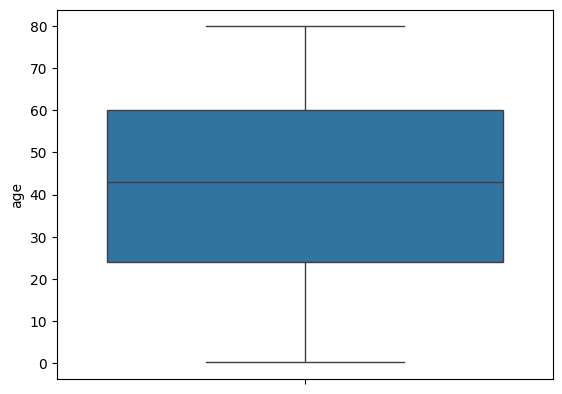

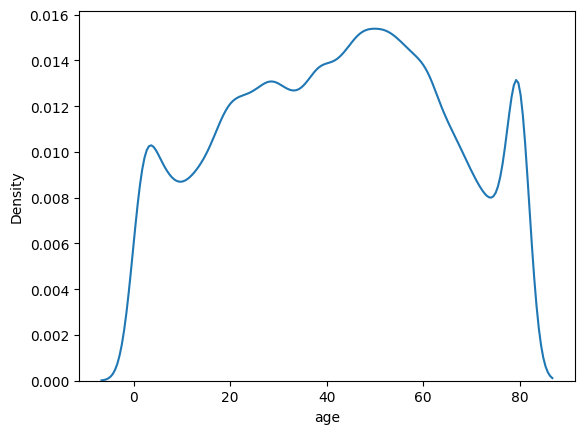

In [33]:
new_df_cap = diabetes.copy()

new_df_cap['age'] = np.where(new_df_cap['age'] > Upper, Upper,
                    np.where(new_df_cap['age'] < lower, lower,
                             new_df_cap['age']))

print("Before capping:",diabetes.shape)
print("After capping:",new_df_cap.shape)

sns.boxplot(new_df_cap['age'])
plt.show()

sns.kdeplot(data = new_df_cap, x = 'age')
plt.show()

# 2. find and mitigate(trimming and capping both) outliers on price column of house dataset

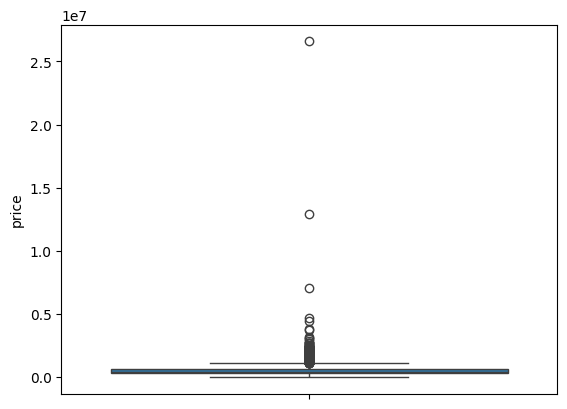

count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

In [34]:
house['price']

sns.boxplot(house['price'])
plt.show()

house['price'].describe()

In [35]:
prec25 = house['price'].quantile(0.25)
prec75 = house['price'].quantile(0.75)

print("25th percentile, Q1: ",prec25)
print("75th percentile, Q3: ",prec75)

IQR = prec75 - prec25
print("IQR: ",IQR)

upper_limit = prec75 + 1.5 * IQR
lower_limit = prec25 - 1.5 * IQR

print("Upper limit: ",upper_limit)
print("Lower limit: ",lower_limit)

# rows where price greater than upper limit
print(house[house['price'] > upper_limit])

# rows where price lower than lower limit
print(house[house['price'] < lower_limit])

25th percentile, Q1:  322875.0
75th percentile, Q3:  654962.5
IQR:  332087.5
Upper limit:  1153093.75
Lower limit:  -175256.25
                     date         price  bedrooms  bathrooms  sqft_living  \
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
11    2014-05-02 00:00:00  1.400000e+06       4.0       2.50         2920   
14    2014-05-02 00:00:00  1.200000e+06       5.0       2.75         2910   
99    2014-05-05 00:00:00  1.395000e+06       5.0       3.50         4010   
122   2014-05-05 00:00:00  2.280000e+06       7.0       8.00        13540   
...                   ...           ...       ...        ...          ...   
4348  2014-05-05 00:00:00  2.199900e+06       4.0       1.50         1120   
4350  2014-07-03 00:00:00  2.659000e+07       3.0       2.00         1180   
4465  2014-06-05 00:00:00  2.560498e+06       3.0       2.50         1710   
4467  2014-06-06 00:00:00  1.337044e+06       4.0       3.50         4280   
4572  2014-07-02 00:00:00 

In [36]:
print("Before trimming:",house.shape)

# the outliers are removed
new_house = house[(house['price'] < upper_limit) & 
                  (house['price'] > lower_limit)]

print("After trimming:",new_house.shape)

new_house

Before trimming: (4600, 18)
After trimming: (4360, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.000000,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
2,2014-05-02 00:00:00,342000.000000,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.000000,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.000000,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.000000,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


Before capping: (4600, 18)
After capping: (4600, 18)


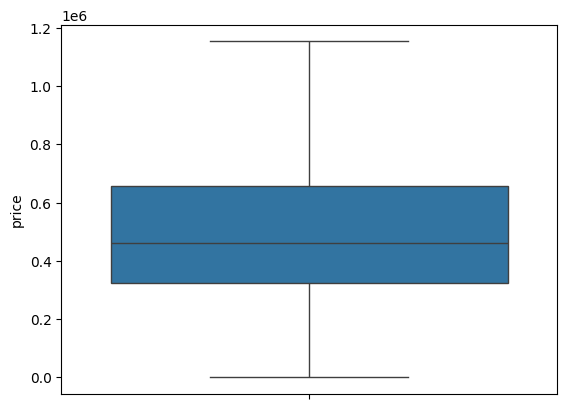

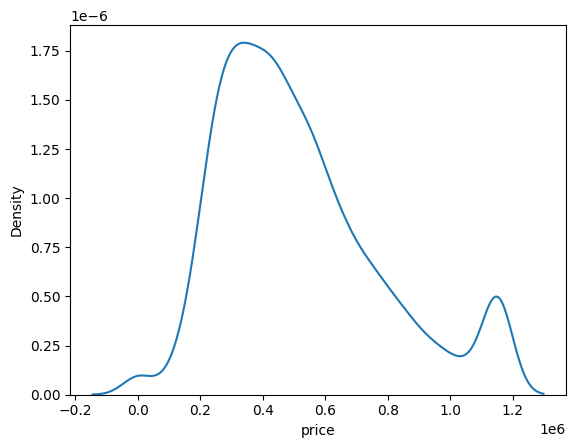

In [37]:
new_house_cap = house.copy()

# upper outliers are replaced by upper limit and lower outliers by lower limit
new_house_cap['price'] = np.where(
    new_house_cap['price'] > upper_limit, upper_limit,
    np.where(
        new_house_cap['price'] < lower_limit,
        lower_limit,
        new_house_cap['price']
    )
)

print("Before capping:",house.shape)
print("After capping:",new_house_cap.shape)

sns.boxplot(new_house_cap['price'])
plt.show()

sns.kdeplot(data = new_house_cap, x = 'price')
plt.show()